In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import ipywidgets as widgets 
from ipywidgets import interact, Dropdown, IntSlider
from scipy.io import loadmat
from scipy.spatial import Delaunay
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
#!pip install scikit-learn
from sklearn.metrics import roc_auc_score
from numpy import random
import os
#!pip install imageio
import imageio

### Load the LUT

In [20]:
lut = loadmat('lookup_table_two_pop.mat')
params = lut['params']     
#If some parameters are not varying, they must be removed from the table to allow the interpolation : here kappa_alive = 0.03
dim_to_remove = 4
#params=[f, Dex, rmean, rsd, kappa_dead, f_alive]
params = np.delete(params, dim_to_remove, axis=1)
signals = lut['signals_4D']            
sequence = lut['sequence']

### Delaunay interpolation

In [21]:
def interpolate_signal_vectorized(params_voxels, bval, TD, delta, bvecs, tri):
    """
    params_voxels : (N_voxels, 6) = [f, Dex, rmean, rsd, kappa_dead, f_alive]
    bvecs         : list of directions for gradient
    tri           : Delaunay(params)
    """

    N_voxels = params_voxels.shape[0]
    signal_interp = np.full(N_voxels, np.nan, dtype=float)  

    # If voxel has less than 10 cells it is considered empty
    mask_nonempty = params_voxels[:, 0] >= 0.007
    signal_interp[~mask_nonempty] = 1.0
    #print(np.sum(mask_nonempty), "non-empty voxels")

    # If the world is empty 
    voxels_idx = np.where(mask_nonempty)[0]
    if voxels_idx.size == 0:
        return signal_interp

    params_nonempty = params_voxels[voxels_idx]

    # Indexes for bval and TD
    TDs   = sequence['TD'][0][0]
    bvals = sequence['bval'][0][0]
    TD_index   = np.where(TDs == TD)[0][0]
    bval_index = np.where(bvals == bval)[0][0]
    bvecs_idx  = np.asarray([int(i) for i in bvecs], dtype=int)

    # Find the simplex for each voxel
    simplex_indices = tri.find_simplex(params_nonempty)   
    #print("find_simplex on", simplex_indices.size, "voxels")

    inside_mask        = (simplex_indices != -1)          # in regards to params_nonempty
    inside_voxel_idx   = voxels_idx[inside_mask]          # global index
    inside_simplex_idx = simplex_indices[inside_mask]     # simplex index

    out_voxel_idx = voxels_idx[~inside_mask]              # globally outside the convex hull
    num_out = out_voxel_idx.size
    #print(num_out, "points outside the convex hull")
    if num_out > 0:
        signal_interp[out_voxel_idx] = 0.0  #if the interpolation failed
        print("Params outside hull:\n", params_voxels[out_voxel_idx, :])

    # Barycentric interpolation
    for i_vox, s_idx in zip(inside_voxel_idx, inside_simplex_idx):
        vertex_index = tri.simplices[s_idx]       # indices of the vertex
        vertices     = tri.points[vertex_index]   # coordinates of the vertex

        v = params_voxels[i_vox] - vertices[0]
        T = vertices[1:] - vertices[0]            

        try:
            bary_tail = np.linalg.solve(T.T, v)  
        except np.linalg.LinAlgError:
            # fallback
            bary_tail, *_ = np.linalg.lstsq(T.T, v, rcond=None)

        bary = np.empty(vertex_index.shape[0], dtype=float)
        bary[1:] = bary_tail
        bary[0]  = 1.0 - bary_tail.sum()

        # Linear combination 
        signals_subset = signals[vertex_index]  
        interpolated   = np.tensordot(bary, signals_subset, axes=(0, 0))  # (nTD, nB, nDirs)

        # Find the values for the acquisition parameters and average over directions
        sig_vals = interpolated[TD_index, bval_index, bvecs_idx]
        signal_interp[i_vox] = np.mean(sig_vals) / 1e5

    return signal_interp



### Necrotic core, f gaussian, Dex constant

In [22]:
#World size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_necrosis_core_rim = np.empty((Nx, Ny, Nz), dtype=object)

# Gaussian mixture for f
center_f = (Nx // 2, Ny // 2, Nz // 2)
gaussian_f = (Nx / 6, 0.8)

# Initialisation des champs 3D
f_field = np.zeros((Nx, Ny, Nz))
Dex_field = np.zeros((Nx, Ny, Nz))

# Necrosis core-rim
cx, cy, cz = Nx//2, Ny//2, Nz//2
R_core   = Nx//2 - 7
R_rim    = R_core + 4

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            d_center = np.linalg.norm([i - Nx // 2, j - Ny // 2, k - Nz // 2])

            if d_center > R_rim:
                # Outside tumor
                f_total = 0.0
                Dex_total = 1.1
            else:
                # f
                d_f = np.linalg.norm([i - center_f[0], j - center_f[1], k - center_f[2]])
                f_total = gaussian_f[1] * np.exp(-d_f**2 / (2 * gaussian_f[0]**2))
                f_total = np.clip(f_total, 0.1, 0.7)

            # Save
            f_field[i, j, k] = f_total


# f_alive min at the core and decreasing radially 
falive_min_core = 0.1   # 90% of dead cells at the core
kappa_dead = 0.25

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            r = np.sqrt((i-cx)**2 + (j-cy)**2 + (k-cz)**2)
            if r <= R_core:
                # necrotic core
                f_dead = (1-falive_min_core) * (1 - r/R_core)  # decreasing near the edges of the tumor
                f_dead = np.clip(f_dead,0.2,0.9)
            else :
                f_dead = 0.2
            f_alive = 1 - f_dead

            AMBER_map_necrosis_core_rim[i,j,k] = {
                "f": f_field[i, j, k],
                "f_alive": f_alive,
                "Dex": 2,
                "rmean": 20,
                "rsd": 5,
                "kappa_dead": kappa_dead
            }


### Necrotic core, f and Dex constant

In [23]:
#World size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_necrosis_basic = np.empty((Nx, Ny, Nz), dtype=object)

# Initialisation des champs 3D
f_field = np.zeros((Nx, Ny, Nz))
Dex_field = np.zeros((Nx, Ny, Nz))

# Necrosis core-rim
cx, cy, cz = Nx//2, Ny//2, Nz//2
R_core   = Nx//2 - 5
R_rim    = R_core + 1

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            d_center = np.linalg.norm([i - Nx // 2, j - Ny // 2, k - Nz // 2])

            if d_center > R_rim:
                # Outside tumor
                f_total = 0.0
                Dex_total = 1.1
            else:
                # f
                f_total = 0.5
                Dex_total = 2

            # Save
            f_field[i, j, k] = f_total
            Dex_field[i, j, k] = Dex_total


# f_alive min at the core and decreasing radially 
falive_min_core = 0.1   # 50% of dead cells at the core
kappa_dead = 0.2

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            r = np.sqrt((i-cx)**2 + (j-cy)**2 + (k-cz)**2)
            if r <= R_core:
                # necrotic core
                f_dead = (1-falive_min_core) * (1 - r/R_core)  # decreasing near the edges of the tumor
                f_dead = np.clip(f_dead,0.2,0.9)
            else :
                f_dead = 0.2
            f_alive = 1 - f_dead

            AMBER_map_necrosis_basic[i,j,k] = {
                "f": f_field[i, j, k],
                "f_alive": f_alive,
                "Dex": Dex_field[i, j, k],
                "rmean": 20,
                "rsd": 5,
                "kappa_dead": kappa_dead
            }


### High heterogeneity in necrosis

In [36]:
# For reproductibility
np.random.seed(42)

# World size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_patchy = np.empty((Nx, Ny, Nz), dtype=object)

# Gaussian mixture for f
center_f = (Nx // 2, Ny // 2, Nz // 2)
gaussian_f = (Nx / 6, 0.75)

# Global parameters 
Dex_viable   = 2.0
Dex_necrosis = 2.0 #put lower values in necrotic areas influences a lot the signal value
rmean        = 20
rsd          = 5

# % of necrotic voxels
necrosis_fraction = 0.3   # 15% of the tumor
patch_radius      = 2      # typical size of necrotic patch
kappa_dead_high   = 0.25
f_dead_high       = 0.7

# Center of tumor
cx, cy, cz = Nx//2, Ny//2, Nz//2
R_tumor    = Nx//2 - 3

# Initialize the "viable" tumor
for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            d_center = np.linalg.norm([i - cx, j - cy, k - cz])
            if d_center <= R_tumor:
                d_f = np.linalg.norm([i - center_f[0], j - center_f[1], k - center_f[2]])
                f_total = gaussian_f[1] * np.exp(-d_f**2 / (2 * gaussian_f[0]**2))
                f_total = np.clip(f_total, 0.1, 0.7)
                f_alive = 0.9
                Dex     = Dex_viable
            else:
                f_alive = 1
                Dex     = 1.1  # outside
                f_total = 0
            AMBER_map_patchy[i,j,k] = {
                "f": f_total,
                "f_alive": f_alive,
                "Dex": Dex,
                "rmean": rmean,
                "rsd": rsd,
                "kappa_dead": 0.09
            }

# Add necrotic corse
n_patches = int(necrosis_fraction * (4/3*np.pi*R_tumor**3) / (4/3*np.pi*patch_radius**3))
print(n_patches)

for _ in range(n_patches):
    # find random center for the patches
    while True:
        x0 = random.randint(cx-R_tumor, cx+R_tumor)
        y0 = random.randint(cy-R_tumor, cy+R_tumor)
        z0 = random.randint(cz-R_tumor, cz+R_tumor)
        if np.linalg.norm([x0-cx, y0-cy, z0-cz]) <= R_tumor:
            break

    # assign necrotic patches
    for i in range(Nx):
        for j in range(Ny):
            for k in range(Nz):
                r = np.linalg.norm([i-x0, j-y0, k-z0])
                if r <= patch_radius and np.linalg.norm([i-cx, j-cy, k-cz]) <= R_tumor:
                    AMBER_map_patchy[i,j,k]["f_alive"]    = 1 - f_dead_high
                    AMBER_map_patchy[i,j,k]["Dex"]        = Dex_necrosis
                    AMBER_map_patchy[i,j,k]["kappa_dead"] = kappa_dead_high

print("Patchy necrosis map created with", n_patches, "patches.")


27
Patchy necrosis map created with 27 patches.


### Kappa_dead influence

In [25]:
#World size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_necrosis_kappa = np.empty((Nx, Ny, Nz), dtype=object)

# Initialisation des champs 3D
f_field = np.zeros((Nx, Ny, Nz))
Dex_field = np.zeros((Nx, Ny, Nz))

# Necrosis core-rim
cx, cy, cz = Nx//2, Ny//2, Nz//2
R_core   = Nx//2 - 5
R_rim    = R_core + 1

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            d_center = np.linalg.norm([i - Nx // 2, j - Ny // 2, k - Nz // 2])

            if d_center > R_rim:
                # Outside tumor
                f_total = 0.0
                Dex_total = 1.1
            else:
                # f
                f_total = 0.5
                Dex_total = 2

            # Save
            f_field[i, j, k] = f_total
            Dex_field[i, j, k] = Dex_total


# f_alive min at the core and decreasing radially 
falive_min_core = 0.1   # 50% of dead cells at the core
kappa_dead_core = 0.3
kappa_dead_constant = 0.15

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            r = np.sqrt((i-cx)**2 + (j-cy)**2 + (k-cz)**2)
            if r <= R_core:
                # necrotic core
                f_dead = (1-falive_min_core) * (1 - r/R_core)  # decreasing near the edges of the tumor
                f_dead = np.clip(f_dead,0.2,0.9)
                kappa_dead = kappa_dead_core * (1 - r/R_core)  # decreasing near the edges of the tumor
                kappa_dead = np.clip(kappa_dead,0.045,0.25)
            else :
                f_dead = 0.2
                kappa_dead = 0.05
            f_alive = 1 - f_dead

            AMBER_map_necrosis_kappa[i,j,k] = {
                "f": f_field[i, j, k],
                "f_alive": f_alive,
                "Dex": Dex_field[i, j, k],
                "rmean": 20,
                "rsd": 5,
                "kappa_dead": kappa_dead
            }

### Dex hides necrosis

In [26]:
#World size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_necrosis_core_dex = np.empty((Nx, Ny, Nz), dtype=object)

# Gaussian mixture for f
center_f = (Nx // 2, Ny // 2, Nz // 2)
gaussian_f = (Nx / 6, 0.8)

# Gaussian mixture for Dex
center_Dex = (Nx // 2, Ny // 2, Nz // 2)
gaussian_Dex = (Nx / 6, 1.5)

# Initialisation des champs 3D
f_field = np.zeros((Nx, Ny, Nz))
Dex_field = np.zeros((Nx, Ny, Nz))

# Necrosis core-rim
cx, cy, cz = Nx//2, Ny//2, Nz//2
R_core   = Nx//2 - 7
R_rim    = R_core + 4

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            d_center = np.linalg.norm([i - Nx // 2, j - Ny // 2, k - Nz // 2])

            if d_center > R_rim:
                # Outside tumor
                f_total = 0.0
                Dex_total = 1.1
            else:
                # f
                d_f = np.linalg.norm([i - center_f[0], j - center_f[1], k - center_f[2]])
                f_total = gaussian_f[1] * np.exp(-d_f**2 / (2 * gaussian_f[0]**2))
                f_total = np.clip(f_total, 0.1, 0.7)
                Dex_total = 2.5 - gaussian_Dex[1] * np.exp(-d_f**2 / (2 * gaussian_Dex[0]**2))
                Dex_total = np.clip(Dex_total, 1.2, 2.5)

            # Save
            f_field[i, j, k] = f_total
            Dex_field[i, j, k] = Dex_total


# f_alive min at the core and decreasing radially 
falive_min_core = 0.1   # 50% of dead cells at the core
kappa_dead_core = 0.3
kappa_dead_constant = 0.15

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            r = np.sqrt((i-cx)**2 + (j-cy)**2 + (k-cz)**2)
            if r <= R_core:
                # necrotic core
                f_dead = (1-falive_min_core) * (1 - r/R_core)  # decreasing near the edges of the tumor
                f_dead = np.clip(f_dead,0.2,0.9)
                kappa_dead = kappa_dead_core * (1 - r/R_core)  # decreasing near the edges of the tumor
                kappa_dead = np.clip(kappa_dead,0.05,0.25)
            else :
                f_dead = 0.2
                kappa_dead = 0.05
            f_alive = 1 - f_dead

            AMBER_map_necrosis_core_dex[i,j,k] = {
                "f": f_field[i, j, k],
                "f_alive": f_alive,
                "Dex": Dex_field[i, j, k],
                "rmean": 20,
                "rsd": 5,
                "kappa_dead": kappa_dead
            }


### Necrosis and Dex core rim

In [27]:
# World size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_necrosis_core_rim_Dex = np.empty((Nx, Ny, Nz), dtype=object)

# Gaussian mixture for f
center_f = (Nx // 2, Ny // 2, Nz // 2)
gaussian_f = (Nx / 6, 0.8)

# Initialisation des champs 3D
f_field = np.zeros((Nx, Ny, Nz))
Dex_field = np.zeros((Nx, Ny, Nz))

# Tumor geometry
cx, cy, cz = Nx//2, Ny//2, Nz//2
R_core   = Nx//2 - 7   # radius necrotic core
R_rim    = R_core + 4  # viable rim thickness

# ---------- Compute fraction field f ----------
for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            d_center = np.linalg.norm([i - cx, j - cy, k - cz])
            if d_center > R_rim:
                # Outside tumor
                f_total = 0.0
            else:
                # Gaussian falloff for cell density
                d_f = np.linalg.norm([i - center_f[0], j - center_f[1], k - center_f[2]])
                f_total = gaussian_f[1] * np.exp(-d_f**2 / (2 * gaussian_f[0]**2))
                f_total = np.clip(f_total, 0.1, 0.7)
            f_field[i, j, k] = f_total

# ---------- Parameters ----------
falive_min_core = 0.1   # 90% of dead cells at the core
kappa_dead_max = 0.25

# Dex profile (µm²/ms)
Dex_rim   = 2.0   # viable rim
Dex_core  = 1.5   # necrosis established
Dex_cavity = 3.0  # central cavity (late necrosis)

# ---------- Build map ----------
for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            r = np.sqrt((i-cx)**2 + (j-cy)**2 + (k-cz)**2)

            if r <= R_core:
                # Necrotic core
                f_dead = (1-falive_min_core) * (1 - r/R_core)
                f_dead = np.clip(f_dead, 0.2, 0.9)
                f_alive = 1 - f_dead

                # Dex profile: low in necrotic shell, high at very center
                if r < R_core*0.3:   # central cavity (inner 30%)
                    Dex = Dex_cavity
                else:
                    Dex = Dex_core

                #kappa proportional ot f_dead
                kappa_dead = kappa_dead_max * (1 - r/R_core)
                kappa_dead = np.clip(kappa_dead, 0.06, 0.25)
            elif r <= R_rim:
                # Viable rim
                f_dead = 0.2
                f_alive = 0.8
                Dex = Dex_rim
                kappa_dead = 0.06
            else:
                # Outside tumor
                f_dead = 0.9
                f_alive = 0.1
                Dex = 1.5  # background
                kappa = 0.06

            AMBER_map_necrosis_core_rim_Dex[i,j,k] = {
                "f": f_field[i, j, k],
                "f_alive": f_alive,
                "Dex": Dex,
                "rmean": 20,
                "rsd": 5,
                "kappa_dead": kappa_dead
            }


### Download 3D maps

In [28]:
def save_slices_as_png(AMBER_map, quantity="f_dead", output_dir="slices_output", cmap="magma", vmin=0, vmax=1):
    """
    Save each slice of a given quantity as PNG images.

    Parameters
    ----------
    AMBER_map : 3D numpy object array
        The AMBER map.
    quantity : str
        One of ["f", "f_dead", "Dex"]. "f_dead" = (1 - f_alive) * f
    output_dir : str
        Folder where PNGs will be saved.
    cmap : str
        Colormap for plotting.
    vmin, vmax : float
        Color limits.
    """
    N = AMBER_map.shape[0]
    os.makedirs(output_dir, exist_ok=True)

    # Build the 3D array for the chosen quantity
    data_map = np.zeros((N, N, N))
    for i in range(N):
        for j in range(N):
            for k in range(N):
                voxel = AMBER_map[i, j, k]
                if quantity == "f":
                    data_map[i,j,k] = voxel["f"]
                elif quantity == "f_dead":
                    data_map[i,j,k] = (1 - voxel["f_alive"]) * voxel["f"]
                elif quantity == "Dex":
                    data_map[i,j,k] = voxel["Dex"]
                else:
                    raise ValueError("Unknown quantity")

    # Save each slice as PNG
    for k in tqdm(range(N), desc=f"Saving {quantity} slices"):
        fig, ax = plt.subplots(figsize=(5,5))
        im = ax.imshow(data_map[:, :, k], cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(f"{quantity} slice {k}")
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"{quantity}_slice_{k:03d}.png"), dpi=150)
        plt.close(fig)

    print(f"All slices saved in {output_dir}")

def make_gif_from_slices(output_dir="slices_output", quantity="f_dead", gif_name="f_dead.gif", duration=0.2):
    """
    Create a GIF from saved PNG slices.
    """
    files = sorted([f for f in os.listdir(output_dir) if f.startswith(quantity) and f.endswith(".png")])
    images = [imageio.imread(os.path.join(output_dir, f)) for f in files]
    imageio.mimsave(os.path.join(output_dir, gif_name), images, duration=duration)
    print(f"GIF saved as {os.path.join(output_dir, gif_name)}")

# Exemple d'utilisation :
save_slices_as_png(AMBER_map_patchy, quantity="f_dead", output_dir="necrosis_slices", cmap="magma", vmin=0, vmax=1)
make_gif_from_slices(output_dir="necrosis_slices", quantity="f_dead", gif_name="necrosis.gif", duration=0.2)

Saving f_dead slices: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:03<00:00,  7.78it/s]
/var/folders/kv/cm0x8gz16zs51vl817b93hh00000gn/T/ipykernel_57862/4081415406.py:53: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(os.path.join(output_dir, f)) for f in files]


All slices saved in necrosis_slices
GIF saved as necrosis_slices/necrosis.gif


## Interactive interface

In [39]:
#Values depending on the LUT
bval_options = [0, 0.25, 0.5, 0.7, 0.8, 1.0, 1.2, 1.6, 2.0, 3.5]
TD_options = [15, 45, 75]
delta_options = [4]
bvecs_options_dict = {
    "0": np.array([1, 0, 1]) / np.sqrt(2),
    "1": np.array([-1, 0, 1]) / np.sqrt(2),
    "2": np.array([0, 1, 1]) / np.sqrt(2),
    "3": np.array([0, 1, -1]) / np.sqrt(2),
    "4": np.array([1, 1, 0]) / np.sqrt(2),
    "5": np.array([-1, 1, 0]) / np.sqrt(2),
}
#Create a triangulation is parameters space
tri = Delaunay(params)
print("Triangulation done")

def interactive_plot(AMBER_map):
    N = AMBER_map.shape[0]
    @interact(
        bval = widgets.Dropdown(options=bval_options, value=0.5, description="Bvalue"),
        TD = widgets.Dropdown(options=TD_options, value=45, description="TD"),
        delta = widgets.Dropdown(options=delta_options, value=4, description="Pulse width"),
        bvecs = widgets.SelectMultiple(
            options=list(bvecs_options_dict.keys()),
            value=("0","1","2","3","4","5"),
            description="Directions",
            layout=widgets.Layout(height="150px")
        ),
        slice_index_DWI=IntSlider(min=0, max=N-1, step=1, value=N//2, description='Slice'),
        slice_index_f=widgets.IntSlider(min=0, max=N-1, step=1, value=N//2, description="Density slice"),
        slice_index_f_dead=widgets.IntSlider(min=0, max=N-1, step=1, value=N//2, description="Necrosis density slice"),
        slice_index_Dex=widgets.IntSlider(min=0, max=N-1, step=1, value=N//2, description="Dex slice"),
        vmin_signal=widgets.FloatSlider(min=0, max=1, step=0.01, value=0, description="Signal vmin"),
        vmax_signal=widgets.FloatSlider(min=0, max=1, step=0.01, value=1, description="Signal vmax")
    )
    def plot_DWI(bval, TD, delta, bvecs, slice_index_DWI, slice_index_f, slice_index_f_dead, slice_index_Dex, vmin_signal, vmax_signal):
        signal_map = np.zeros((N,) * 3)
        density_map = np.zeros((N,) * 3)
        necrosis_map = np.zeros((N,) * 3)
        Dex_map = np.zeros((N,) * 3)
        params_voxels = np.zeros((N**3, 6))
        idx_flat = 0
        for i in tqdm(range(N), desc="Processing slices"):
            for j in range(N):
                for k in range(N):
                    voxel = AMBER_map[i,j,k]
                    params_voxels[idx_flat, :] = [
                        voxel['f'], voxel['Dex'], voxel['rmean'],
                        voxel['rsd'], voxel['kappa_dead'], voxel['f_alive']
                    ]
                    idx_flat += 1
                    density_map[i, j, k] = voxel['f']
                    necrosis_map[i, j, k] = (1-voxel['f_alive'])
                    Dex_map[i, j, k] = voxel['Dex']
        signal = interpolate_signal_vectorized(params_voxels, bval, TD, delta, bvecs, tri)
        signal_map = signal.reshape((N, N, N))

        fig, axs = plt.subplots(1, 4, figsize=(15,5))
        
        # --- DWI ---
        im0 = axs[0].imshow(signal_map[:, :, slice_index_DWI], cmap='gray', origin='lower', 
                            vmin=vmin_signal, vmax=vmax_signal)
        axs[0].set_title(f"DWI slice (b={bval}ms/µm², TD={TD}ms, δ={delta}ms)")
        divider0 = make_axes_locatable(axs[0])
        cax0 = divider0.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im0, cax=cax0)
        
        # --- f ---
        im1 = axs[1].imshow(density_map[:, :, slice_index_f], cmap='viridis', origin='lower', vmin=0, vmax=1)
        axs[1].set_title("f : Cell density")
        divider1 = make_axes_locatable(axs[1])
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im1, cax=cax1)
        
        # --- f_dead ---
        #im2 = axs[2].imshow(necrosis_map[:, :, slice_index_f_dead], cmap='magma', origin='lower', vmin=0, vmax=1)
        #axs[2].set_title("f_dead : Dead cell density")
        #divider2 = make_axes_locatable(axs[2])
        #cax2 = divider2.append_axes("right", size="5%", pad=0.05)
        #plt.colorbar(im2, cax=cax2)

        # Créer une copie pour affichage
        f_dead_thresholded = np.copy(necrosis_map)
        f_dead_thresholded[f_dead_thresholded < 0.6] = np.nan  # met NaN pour rendre transparent
        im2 = axs[2].imshow(f_dead_thresholded[:, :, slice_index_f_dead], cmap='magma', origin='lower', vmin=0, vmax=1)
        axs[2].set_title("f_dead >= 0.6 (highlighted)")
        divider2 = make_axes_locatable(axs[2])
        cax2 = divider2.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im2, cax=cax2, label="f_dead")

        # --- Dex ---
        im3 = axs[3].imshow(Dex_map[:, :, slice_index_Dex], cmap='cool', origin='lower', vmin=0.1, vmax=3)
        axs[3].set_title("Dex : Extracellular diffusivity (µm²/ms)")
        divider3 = make_axes_locatable(axs[3])
        cax3 = divider3.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im3, cax=cax3)
        
        plt.tight_layout()
        if not os.path.exists('Figures'):
            os.mkdir('Figures')
        
        fig.savefig('Figures/Nec_dex.png', dpi=300, bbox_inches='tight')  # dpi=300 pour haute qualité
        plt.show()


interactive_plot(AMBER_map_necrosis_core_rim_Dex)

Triangulation done


interactive(children=(Dropdown(description='Bvalue', index=2, options=(0, 0.25, 0.5, 0.7, 0.8, 1.0, 1.2, 1.6, …

### Heatmap to determine the best parameters to show higher contrast 

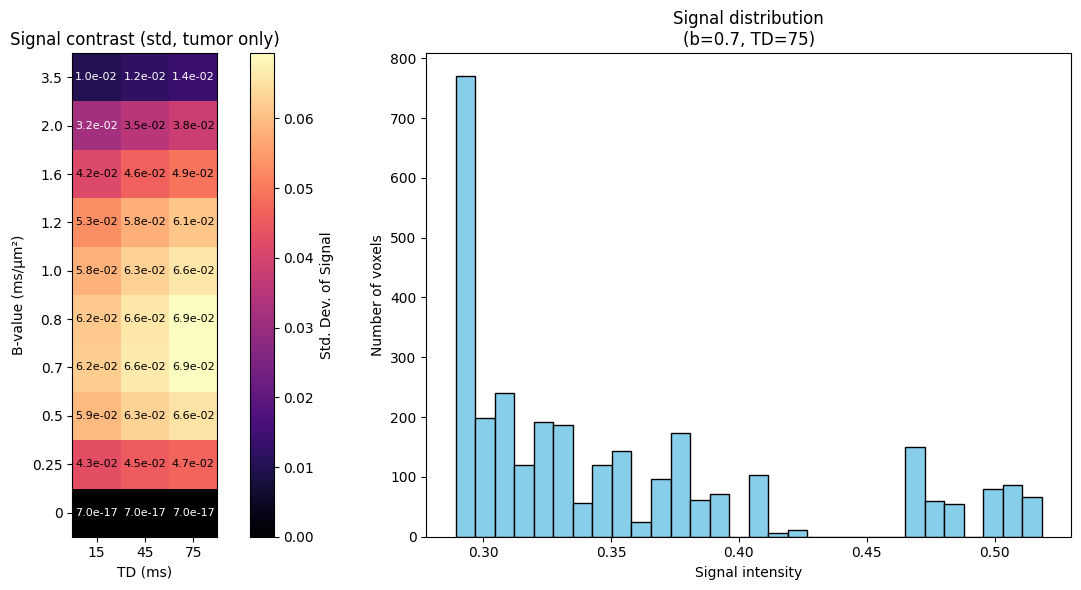

In [41]:
def plot_parameter_contrast_heatmap_tumor_only(AMBER_map, delta=4, bvecs=("0", "1", "2", "3", "4", "5"),
                                                hist_bval=0.5, hist_TD=45):

    N = AMBER_map.shape[0]
    contrast_matrix = np.zeros((len(bval_options), len(TD_options)))
    tri = Delaunay(params)

    # --- Extraction of voxel in 1D ---
    f_map    = np.array([AMBER_map[i, j, k]["f"]     for i in range(N) for j in range(N) for k in range(N)])
    Dex_map  = np.array([AMBER_map[i, j, k]["Dex"]   for i in range(N) for j in range(N) for k in range(N)])
    rmean_map= np.array([AMBER_map[i, j, k]["rmean"] for i in range(N) for j in range(N) for k in range(N)])
    rsd_map  = np.array([AMBER_map[i, j, k]["rsd"]   for i in range(N) for j in range(N) for k in range(N)])
    kappa_dead_map  = np.array([AMBER_map[i, j, k]["kappa_dead"]   for i in range(N) for j in range(N) for k in range(N)])
    f_alive_map  = np.array([AMBER_map[i, j, k]["f_alive"]   for i in range(N) for j in range(N) for k in range(N)])

    # --- Keep only voxels inside the tumor ---
    mask_tumor = f_map >= 0.007
    params_voxels = np.column_stack([
        f_map[mask_tumor],
        Dex_map[mask_tumor],
        rmean_map[mask_tumor],
        rsd_map[mask_tumor],
        kappa_dead_map[mask_tumor],
        f_alive_map[mask_tumor]
    ])

    selected_signal_values = None

    # --- Loop (bval, TD) ---
    for i_bval, bval in enumerate(bval_options):
        for i_TD, TD in enumerate(TD_options):
            signals = interpolate_signal_vectorized(params_voxels, bval, TD, delta, bvecs, tri)

            contrast_matrix[i_bval, i_TD] = np.std(signals)

            if bval == hist_bval and TD == hist_TD:
                selected_signal_values = signals

    # --- Plot ---
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Heatmap
    im = axs[0].imshow(contrast_matrix, cmap='magma', origin='lower')
    axs[0].set_xticks(np.arange(len(TD_options)))
    axs[0].set_xticklabels(TD_options)
    axs[0].set_yticks(np.arange(len(bval_options)))
    axs[0].set_yticklabels(bval_options)
    axs[0].set_xlabel("TD (ms)")
    axs[0].set_ylabel("B-value (ms/μm²)")
    axs[0].set_title("Signal contrast (std, tumor only)")
    plt.colorbar(im, ax=axs[0], label="Std. Dev. of Signal")

    # Write std
    for i in range(len(bval_options)):
        for j in range(len(TD_options)):
            value = contrast_matrix[i, j]
            axs[0].text(j, i, f"{value:.1e}", ha='center', va='center',
                        color='white' if value < 0.5 * np.max(contrast_matrix) else 'black', fontsize=8)

    # Histogram
    if selected_signal_values is not None:
        axs[1].hist(selected_signal_values, bins=30, color='skyblue', edgecolor='black')
        axs[1].set_xlabel("Signal intensity")
        axs[1].set_ylabel("Number of voxels")
        axs[1].set_title(f"Signal distribution\n(b={hist_bval}, TD={hist_TD})")
    else:
        axs[1].text(0.5, 0.5, "No tumor signal values found", ha='center', va='center')
        axs[1].set_axis_off()

    plt.tight_layout()
    plt.show()

plot_parameter_contrast_heatmap_tumor_only(AMBER_map_necrosis_core_rim_Dex, 4, ("0","1","2","3","4","5"), 0.7, 75)

### Scores to differentiate necrotic areas from viable areas and heatmap

Tumor voxels: 3071, necrotic: 7, viable: 3064
Top combos:


,bval,TD,mu_nec,var_nec,mu_viab,var_viab,CNR,Cohen_d,AUC,n_nec,n_viab
21,2.0,15,0.106551,0.000018,0.068614,0.000993,1.193189,1.204978,0.834204,7,3064
18,1.6,15,0.155772,0.000025,0.107032,0.001740,1.160364,1.169725,0.834204,7,3064
24,3.5,15,0.029016,0.000004,0.017218,0.000103,1.140665,1.162388,0.829355,7,3064
15,1.2,15,0.232601,0.000031,0.173631,0.002814,1.105557,1.112677,0.834204,7,3064
12,1.0,15,0.287318,0.000032,0.224870,0.003378,1.069355,1.075445,0.834204,7,3064
9,0.8,15,0.358261,0.000030,0.294813,0.003787,1.026915,1.032037,0.834204,7,3064
6,0.7,15,0.401734,0.000028,0.339201,0.003857,1.003263,1.007927,0.834204,7,3064
3,0.5,15,0.510198,0.000021,0.453623,0.003518,0.950935,0.954734,0.834204,7,3064
19,1.6,45,0.158857,0.000069,0.115808,0.002131,0.917749,0.933429,0.823200,7,3064
22,2.0,45,0.109389,0.000050,0.076345,0.001256,0.914392,0.933436,0.820962,7,3064


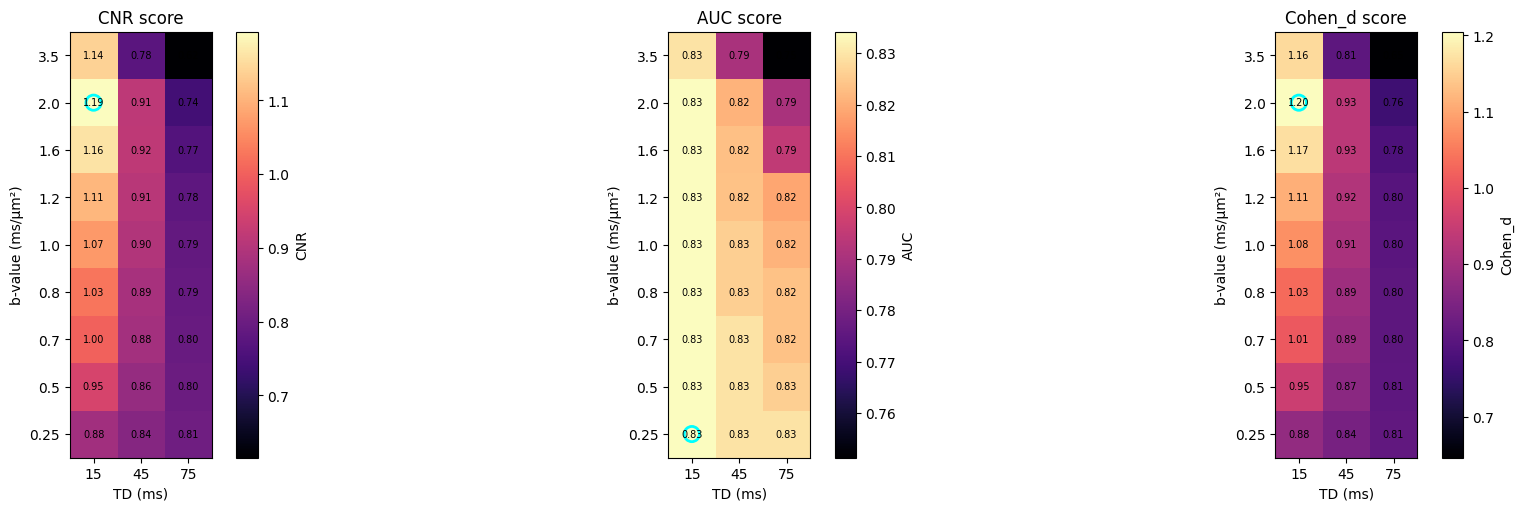

In [45]:
# --- Parameters ---
AMBER_map = AMBER_map_necrosis_core_rim_Dex
f_min_tumor = 0.007
alive_thresh = 0.3
delta = 4
bvecs = ("0","1","2","3","4","5")

bval_options = [0.25, 0.5, 0.7, 0.8, 1.0, 1.2, 1.6, 2.0, 3.5]
TD_options   = [15, 45, 75]

N = AMBER_map.shape[0]

# Flatten voxel params
f_flat         = np.fromiter((AMBER_map[i,j,k]["f"]          for i in range(N) for j in range(N) for k in range(N)), float)
f_alive_flat   = np.fromiter((AMBER_map[i,j,k]["f_alive"]     for i in range(N) for j in range(N) for k in range(N)), float)
Dex_flat       = np.fromiter((AMBER_map[i,j,k]["Dex"]        for i in range(N) for j in range(N) for k in range(N)), float)
rmean_flat     = np.fromiter((AMBER_map[i,j,k]["rmean"]      for i in range(N) for j in range(N) for k in range(N)), float)
rsd_flat       = np.fromiter((AMBER_map[i,j,k]["rsd"]        for i in range(N) for j in range(N) for k in range(N)), float)
kappa_dead_flat= np.fromiter((AMBER_map[i,j,k]["kappa_dead"] for i in range(N) for j in range(N) for k in range(N)), float)

params_voxels = np.column_stack([f_flat, Dex_flat, rmean_flat, rsd_flat, kappa_dead_flat, f_alive_flat])
# print(np.where(f_alive_flat < 0.3)[0])

# Masks
tumor_mask    = f_flat >= f_min_tumor
necrosis_mask = (f_alive_flat <= alive_thresh) & tumor_mask
viable_mask   = (f_alive_flat  > alive_thresh) & tumor_mask

print(f"Tumor voxels: {tumor_mask.sum()}, necrotic: {necrosis_mask.sum()}, viable: {viable_mask.sum()}")

# --- Loop and compute all scores ---
S_min = 0.02
min_samples = 5
results = []

for ib, bval in enumerate(bval_options):
    for it, TD in enumerate(TD_options):
        sig = interpolate_signal_vectorized(params_voxels, bval, TD, delta, bvecs, tri)
        ok = np.isfinite(sig)

        sig_nec  = sig[necrosis_mask & ok]
        sig_viab = sig[viable_mask  & ok]

        if (sig_nec.size >= min_samples) and (sig_viab.size >= min_samples):
            mu_nec, mu_viab = sig_nec.mean(), sig_viab.mean()
            var_nec, var_viab = sig_nec.var(ddof=1), sig_viab.var(ddof=1)

            denom = var_nec + var_viab
            CNR = abs(mu_nec - mu_viab) / np.sqrt(denom) if denom > 0 else np.nan

            n1, n2 = sig_nec.size, sig_viab.size
            pooled_var = ((n1 - 1)*var_nec + (n2 - 1)*var_viab) / (n1 + n2 - 2) if (n1+n2)>2 else np.nan
            pooled_sd = np.sqrt(pooled_var) if pooled_var>0 else np.nan
            cohens_d = abs(mu_viab - mu_nec) / pooled_sd if pooled_sd and not np.isnan(pooled_sd) else np.nan

            try:
                y = np.concatenate([np.ones(sig_nec.size), np.zeros(sig_viab.size)])
                x = np.concatenate([sig_nec, sig_viab])
                #print("sig_nec (10 premières):", sig_nec[:10])
                #print("sig_viab (10 premières):", sig_viab[:10])
                auc = roc_auc_score(y, x)
                if auc < 0.5:
                    auc = 1 - auc
                #print("Exemple combo:")
                #print("necrosis mean:", sig_nec.mean(), "std:", sig_nec.std(), "n:", sig_nec.size)
                #print("viable   mean:", sig_viab.mean(), "std:", sig_viab.std(), "n:", sig_viab.size)
            except Exception:
                auc = np.nan
        else:
            mu_nec = mu_viab = var_nec = var_viab = Fisher = CNR = cohens_d = rel_diff = mean_signal = auc = np.nan

        results.append({
            "bval": bval, "TD": TD,
            "mu_nec": mu_nec, "var_nec": var_nec,
            "mu_viab": mu_viab, "var_viab": var_viab,
            "CNR": CNR, "Cohen_d": cohens_d,"AUC": auc,
            "n_nec": sig_nec.size if 'sig_nec' in locals() else 0,
            "n_viab": sig_viab.size if 'sig_viab' in locals() else 0
        })

# --- DataFrame complet ---
df = pd.DataFrame(results)

# Filtrer si besoin
df_ranked = df.sort_values(['CNR','AUC'], ascending=[False, False]) if not df.empty else df

print("Top combos:")
display(df_ranked.head(10))

scores_to_plot = ["CNR", "AUC", "Cohen_d"]

fig, axes = plt.subplots(1, len(scores_to_plot), figsize=(6*len(scores_to_plot), 5), 
                         constrained_layout=True)

for ax, score in zip(axes, scores_to_plot):
    mat = np.full((len(bval_options), len(TD_options)), np.nan)
    for _, row in df.iterrows():
        ib = bval_options.index(row["bval"])
        it = TD_options.index(row["TD"])
        mat[ib, it] = row[score]

    im = ax.imshow(mat, cmap="magma", origin="lower")

    # ticks
    ax.set_xticks(np.arange(len(TD_options)))
    ax.set_xticklabels(TD_options)
    ax.set_yticks(np.arange(len(bval_options)))
    ax.set_yticklabels(bval_options)
    ax.set_xlabel("TD (ms)")
    ax.set_ylabel("b-value (ms/µm²)")
    ax.set_title(f"{score} score")

    # annotate values
    vmax = np.nanmax(mat)
    for i in range(len(bval_options)):
        for j in range(len(TD_options)):
            val = mat[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        color="white" if val < 0.5*vmax else "black", fontsize=7)

    # highlight best
    if np.isfinite(mat).any():
        best = np.nanargmax(mat)
        best_ib, best_it = np.unravel_index(best, mat.shape)
        ax.scatter(best_it, best_ib, s=120, facecolors='none',
                   edgecolors='cyan', linewidths=2)

    # add individual colorbar for each heatmap
    fig.colorbar(im, ax=ax, label=score)
    
if not os.path.exists('Figures'):
    os.mkdir('Figures')
        
fig.savefig('Figures/Nec_heatmap_dex.png', dpi=300, bbox_inches='tight')  # dpi=300 pour haute qualité
plt.show()